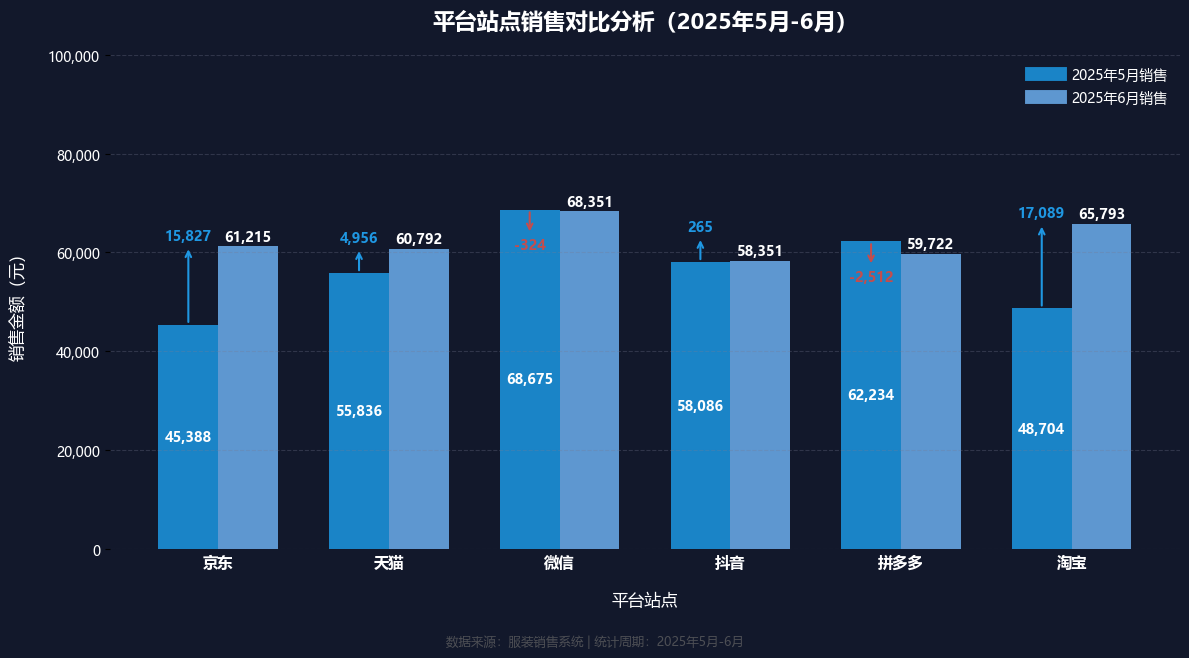

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 读取生成的数据集
try:
    # 严格读取CSV文件
    orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['下单时间', '平台站点', '商品金额']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 转换日期列
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    
    # 过滤无效日期
    orders = orders[orders['下单时间'].notnull()]
    
    # 提取年份和月份
    orders['年份'] = orders['下单时间'].dt.year
    orders['月份'] = orders['下单时间'].dt.month
    
    # 确保只有2025年5月和6月的数据
    orders = orders[(orders['年份'] == 2025) & (orders['月份'].isin([5, 6]))]
    
    if orders.empty:
        raise ValueError("没有2025年5月或6月的订单数据")
    
    # 按平台站点和月份汇总销售数据
    platform_sales = orders.groupby(['平台站点', '月份'])['商品金额'].sum().reset_index()
    
    # 转换为宽格式
    pivot_data = platform_sales.pivot(index='平台站点', columns='月份', values='商品金额').reset_index()
    
    # 确保两个月份都有数据
    for month in [5, 6]:
        if month not in pivot_data.columns:
            pivot_data[month] = 0
    
    # 填充缺失值为0
    pivot_data = pivot_data.fillna(0)
    
    # 转换为数值类型
    pivot_data[5] = pd.to_numeric(pivot_data[5], errors='coerce').fillna(0)
    pivot_data[6] = pd.to_numeric(pivot_data[6], errors='coerce').fillna(0)
    
    # 获取数据
    platforms = pivot_data['平台站点'].tolist()
    sales_may = pivot_data[5].tolist()
    sales_jun = pivot_data[6].tolist()
    
    # 计算销售差异
    differences = [round(sales_jun[i] - sales_may[i]) for i in range(len(sales_jun))]
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#12182B')  # 深蓝色背景
    ax.set_facecolor('#12182B')
    
    # 设置坐标
    x = np.arange(len(platforms))
    bar_width = 0.35
    
    # 创建柱形图
    bars_may = ax.bar(x - bar_width/2, sales_may, bar_width, 
                     label='2025年5月销售', 
                     color='#1a84c7',  # 深蓝色
                     edgecolor='none')
    
    bars_jun = ax.bar(x + bar_width/2, sales_jun, bar_width, 
                     label='2025年6月销售', 
                     color='#5e97d0',  # 浅蓝色
                     edgecolor='none')
    
    # 添加数据标签 - 5月销售（移动到柱体中间）
    for i, bar in enumerate(bars_may):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height/2, 
                f'{int(height):,}', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    
    # 添加数据标签 - 6月销售
    for i, bar in enumerate(bars_jun):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 300, 
                f'{int(height):,}', 
                ha='center', va='bottom', color='white', fontweight='bold', fontsize=10)
    
    # 获取Y轴范围
    max_value = max(max(sales_may), max(sales_jun)) * 1.2
    max_value = int((max_value // 20000) + 1) * 20000
    y_range = max_value
    
    # 设置Y轴
    ax.set_ylim(0, max_value)
    
    # 设置最小箭头长度为Y轴范围的5%
    min_arrow_length = y_range * 0.05
    
    # 添加箭头和标签
    for i in range(len(platforms)):
        # 获取深蓝色柱子（5月销售）的顶部中点位置
        may_bar = bars_may[i]
        x_pos = may_bar.get_x() + may_bar.get_width()/2
        y_start = may_bar.get_height()
        
        # 获取浅蓝色柱子（6月销售）的顶部位置
        y_end = sales_jun[i]
        
        # 计算差异
        diff = differences[i]
        
        # 处理柱体高度接近的情况
        actual_diff = y_end - y_start
        if abs(actual_diff) < min_arrow_length:
            # 使用最小箭头长度
            if diff > 0:
                adjusted_y_end = y_start + min_arrow_length
                arrow_length = min_arrow_length
            else:
                adjusted_y_end = y_start - min_arrow_length
                arrow_length = min_arrow_length
        else:
            adjusted_y_end = y_end
            arrow_length = actual_diff
        
        # 确定箭头颜色
        if diff > 0:
            arrow_color = "#1f97e2"
        else:
            arrow_color = "#c44d4d"
        
        # 计算标签位置 - 始终在箭头正上方
        if diff > 0:
            label_y = adjusted_y_end + 500
            label_va = 'bottom'
        else:
            label_y = adjusted_y_end - 500
            label_va = 'top'
        
        # 添加水平虚线（从深蓝色柱体顶部到浅蓝色柱体顶部）
        ax.plot([x_pos, x_pos], [y_start, y_start], 
                linestyle='--', color='#777b92', alpha=0.5, linewidth=1)
        
        # 添加垂直箭头
        ax.annotate('', 
                    xy=(x_pos, adjusted_y_end), 
                    xytext=(x_pos, y_start),
                    arrowprops=dict(arrowstyle='->', 
                                   color=arrow_color, 
                                   lw=1.5,
                                   connectionstyle='arc3,rad=0.0'))
        
        # 添加差异数值标签 - 始终在箭头正上方
        ax.text(x_pos, label_y, f'{int(diff):,}', 
                ha='center', va=label_va, 
                color=arrow_color, 
                fontweight='bold', 
                fontsize=10)
    
    # 设置Y轴 - 固定20000一格
    y_ticks = np.arange(0, max_value + 1, 20000)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(x):,}' for x in y_ticks], color="#ffffff", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='#777b92')
    
    # 设置X轴
    ax.set_xticks(x)
    ax.set_xticklabels(platforms, color="#ffffff", fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', length=0)
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 添加图例
    blue_patch = Line2D([0], [0], color='#1a84c7', lw=10, label='2025年5月销售')
    light_blue_patch = Line2D([0], [0], color='#5e97d0', lw=10, label='2025年6月销售')
    ax.legend(handles=[blue_patch, light_blue_patch], 
             loc='upper right',
             frameon=False,
             fontsize=10,
             labelcolor="#ffffff")
    
    # 添加标题
    plt.title('平台站点销售对比分析（2025年5月-6月）', fontsize=16, fontweight='bold', color="#ffffff", pad=20)
    "#ffffff"
    plt.xlabel('平台站点', fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel('销售金额（元）', fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加底部装饰
    plt.figtext(0.5, 0.02, 
               '数据来源：服装销售系统 | 统计周期：2025年5月-6月', 
               ha='center', 
               fontsize=9, 
               color='#666666',
               alpha=0.7)
    
    # 调整布局
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('平台站点销售对比分析（2025年5月-6月）.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()
    
except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析：

- **京东**：
  京东平台在2025年5月的销售额为45,388元，6月增长至61,215元，增幅为15,827元，增长率约为34.8%。

- **天猫**：
  天猫平台5月销售额为55,836元，6月增至60,792元，增长了4,956元，增长率约为8.9%。

- **微信**：
  微信平台5月销售额为68,675元，6月略微下降至68,351元，减少了324元，下降率约为0.5%。

- **抖音**：
  抖音平台5月销售额为58,086元，6月增至58,351元，增长了265元，增长率约为0.5%。

- **拼多多**：
  拼多多平台5月销售额为62,234元，6月微降至59,722元，减少了2,512元，下降率约为4.0%。

- **淘宝**：
  淘宝平台5月销售额为48,704元，6月显著增长至65,793元，增加了17,089元，增长率约为35.1%。


# 结论：

从平台站点的销售数据对比分析来看，淘宝在2025年6月的销售额增长最为显著，增长率达到35.1%，显示出其在市场中的强大竞争力和较高的用户活跃度。京东和天猫也表现出较强的销售增长，尤其是京东，其增长率约为34.8%。相比之下，微信平台的销售略有下降，拼多多的销售额也有所减少，这可能反映了这些平台在某些市场细分或用户群体中的相对劣势。这些数据对于理解不同电商平台的市场表现和消费者行为具有重要意义，并为进一步的市场分析和策略制定提供了基础。